#  Experiment 1: Data Exploration

## Quantum Circuit Born Machines for Music Generation

**Objective:** Explore and analyze the Super Mario Bros MIDI file to understand the target distribution for QCBM training.

**Key Questions:**
- What is the structure of the musical data?
- How should we encode pitches for quantum representation?
- Is this a "simple" or "complex" dataset?

---

In [1]:
# Setup and imports
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from src.data.midi_parser import MidiParser
from src.data.encoder import PitchEncoder
from src.data.datasets import SimpleDataset, get_mario_dataset
from src.utils.visualization import set_style, plot_distribution
from src.utils.figure_saver import save_figure
from config import MIDI_DIR, FIGURES_DIR

set_style()
print(" Setup complete!")

 Setup complete!


## 1. Load and Parse MIDI File

In [2]:
# Load the Super Mario Bros MIDI file
midi_path = MIDI_DIR / "mario.mid"
parser = MidiParser(midi_path)
notes = parser.parse()

print(f" MIDI File: {midi_path.name}")
print(f" Total notes extracted: {len(notes)}")
print(f" Duration: {parser.duration_seconds:.1f} seconds")
print(f" Tracks: {parser.n_tracks}")

 MIDI File: mario.mid
 Total notes extracted: 5435
 Duration: 817.5 seconds
 Tracks: 3


In [3]:
# Get detailed statistics
stats = parser.get_statistics()

print("\n STATISTICAL ANALYSIS")
print("=" * 40)
print(f"\n Pitch Statistics:")
print(f"   • Unique pitches: {stats['n_unique_pitches']}")
print(f"   • Range: {stats['pitch_range'][0]} - {stats['pitch_range'][1]}")
print(f"   • Mean: {stats['pitch_mean']:.1f}")
print(f"   • Std: {stats['pitch_std']:.1f}")

print(f"\n Velocity Statistics:")
print(f"   • Unique velocities: {stats['n_unique_velocities']}")
print(f"   • Range: {stats['velocity_range'][0]} - {stats['velocity_range'][1]}")
print(f"   • Mean: {stats['velocity_mean']:.1f}")
print(f"   • Std: {stats['velocity_std']:.1f}")


 STATISTICAL ANALYSIS

 Pitch Statistics:
   • Unique pitches: 61
   • Range: 26 - 95
   • Mean: 60.0
   • Std: 12.9

 Velocity Statistics:
   • Unique velocities: 1
   • Range: 110 - 110
   • Mean: 110.0
   • Std: 0.0


## 2. Visualize Raw Pitch Distribution

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp01_raw_pitch_histogram.png


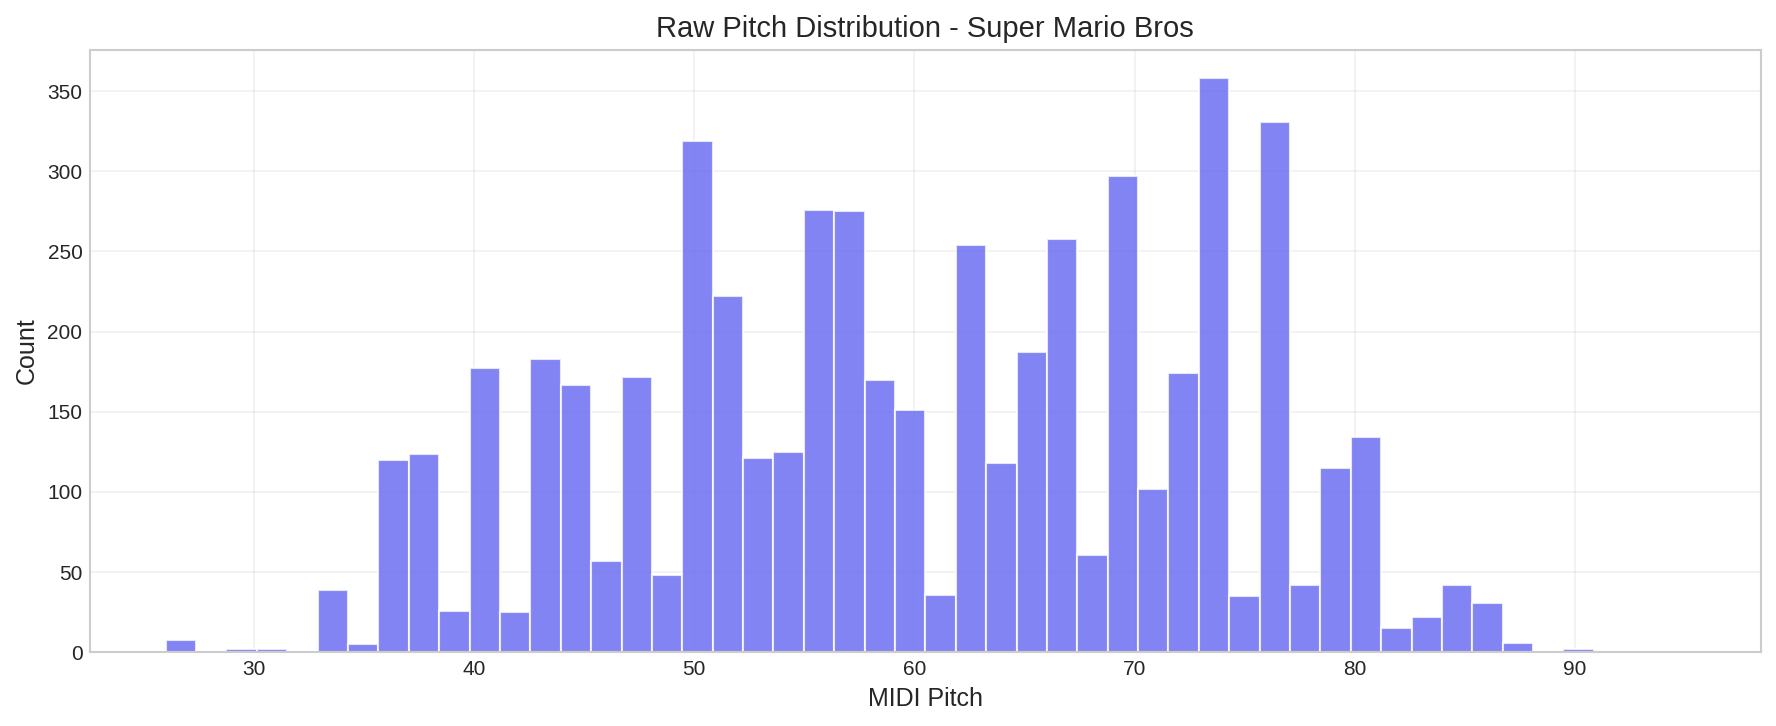


 Top 10 Most Common Notes:
   D3 (MIDI 50): 319 notes (5.9%)
   A3 (MIDI 57): 275 notes (5.1%)
   G4 (MIDI 67): 258 notes (4.7%)
   D5 (MIDI 74): 258 notes (4.7%)
   A4 (MIDI 69): 227 notes (4.2%)
   G3 (MIDI 55): 226 notes (4.2%)
   D4 (MIDI 62): 214 notes (3.9%)
   E3 (MIDI 52): 183 notes (3.4%)
   G2 (MIDI 43): 183 notes (3.4%)
   C5 (MIDI 72): 174 notes (3.2%)


In [4]:
# Get raw pitches
pitches = parser.get_pitches()

# Plot histogram
fig, ax = plt.subplots(figsize=(12, 5))

# Convert MIDI pitch to note names for x-axis
note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

ax.hist(pitches, bins=50, color='#6366F1', edgecolor='white', alpha=0.8)
ax.set_xlabel('MIDI Pitch')
ax.set_ylabel('Count')
ax.set_title('Raw Pitch Distribution - Super Mario Bros')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'raw_pitch_histogram', experiment='exp01')
plt.show()

# Show top 10 most common notes
print("\n Top 10 Most Common Notes:")
pitch_counts = Counter(pitches)
for pitch, count in pitch_counts.most_common(10):
    note = note_names[pitch % 12]
    octave = pitch // 12 - 1
    pct = 100 * count / len(pitches)
    print(f"   {note}{octave} (MIDI {pitch}): {count} notes ({pct:.1f}%)")

## 3. Encode for Quantum Representation (4 Qubits)

For quantum processing, we need to discretize the pitches into $2^n$ bins, where $n$ is the number of qubits.

With **4 qubits**, we have **16 possible states** (bins).

In [5]:
# Create encoder with 4 qubits
encoder = PitchEncoder(
    n_qubits=4,
    pitch_min=int(pitches.min()),
    pitch_max=int(pitches.max()) + 1
)

print(f" Encoder Configuration:")
print(f"   • Qubits: {encoder.n_qubits}")
print(f"   • States: {encoder.n_bins}")
print(f"   • Pitch range: [{encoder.pitch_min}, {encoder.pitch_max}]")

# Encode pitches
encoded_pitches = encoder.encode(pitches)
target_distribution = encoder.get_distribution(pitches)

print(f"\n Target Distribution:")
for i, prob in enumerate(target_distribution):
    if prob > 0.01:  # Only show significant bins
        binary = encoder.index_to_binary(i)
        print(f"   State |{binary}⟩ (bin {i}): {prob:.4f}")

 Encoder Configuration:
   • Qubits: 4
   • States: 16
   • Pitch range: [26, 96]

 Target Distribution:
   State |0010⟩ (bin 2): 0.0506
   State |0011⟩ (bin 3): 0.0708
   State |0100⟩ (bin 4): 0.0523
   State |0101⟩ (bin 5): 0.1290
   State |0110⟩ (bin 6): 0.0960
   State |0111⟩ (bin 7): 0.1097
   State |1000⟩ (bin 8): 0.1052
   State |1001⟩ (bin 9): 0.1047
   State |1010⟩ (bin 10): 0.1295
   State |1011⟩ (bin 11): 0.0751
   State |1100⟩ (bin 12): 0.0486
   State |1101⟩ (bin 13): 0.0178


/tmp/ipykernel_169429/887689075.py:17: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../src/utils/figure_saver.py:67: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Liberation Sans.
  fig.savefig(filepath, dpi=dpi, format=format, bbox_inches=bbox,
/home/jacopo/Documenti/Trento/QuantumML/MusicProject/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp01_target_distribution.png


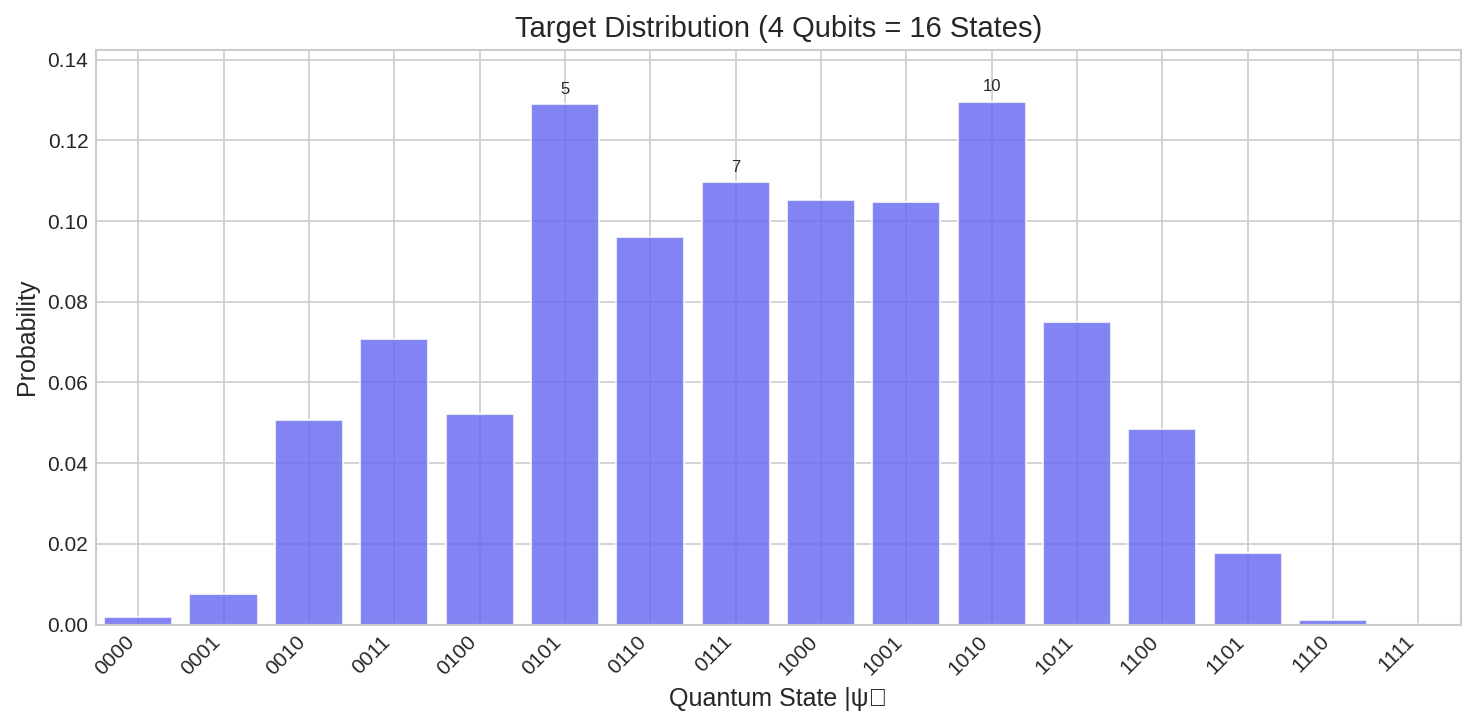

In [6]:
# Visualize the target distribution
fig, ax = plt.subplots(figsize=(10, 5))

plot_distribution(
    target_distribution,
    title='Target Distribution (4 Qubits = 16 States)',
    ax=ax,
    xlabel='Quantum State |ψ⟩',
    show_top_k=3
)

# Add binary labels
binary_labels = [encoder.index_to_binary(i) for i in range(16)]
ax.set_xticks(range(16))
ax.set_xticklabels(binary_labels, rotation=45, ha='right')

plt.tight_layout()
save_figure(fig, 'target_distribution', experiment='exp01')
plt.show()

## 4. Information-Theoretic Analysis

In [7]:
# Compute entropy and effective dimension
from src.utils.metrics import compute_entropy, compute_effective_dimension

entropy = compute_entropy(target_distribution)
max_entropy = np.log2(len(target_distribution))
effective_dim = compute_effective_dimension(target_distribution, threshold=0.01)

print(" Information-Theoretic Analysis")
print("=" * 40)
print(f"\n Shannon Entropy: {entropy:.2f} bits")
print(f"   Maximum possible: {max_entropy:.2f} bits (uniform)")
print(f"   Efficiency: {100 * entropy / max_entropy:.1f}%")

print(f"\n Effective Dimension: {effective_dim} / {len(target_distribution)} states")
print(f"   Sparsity: {100 * (1 - effective_dim / len(target_distribution)):.1f}%")

 Information-Theoretic Analysis

 Shannon Entropy: 3.51 bits
   Maximum possible: 4.00 bits (uniform)
   Efficiency: 87.8%

 Effective Dimension: 12 / 16 states
   Sparsity: 25.0%


## 5. Correlation Analysis (Pitch vs Velocity)

In [8]:
# Check if pitch and velocity are correlated
velocities = parser.get_velocities()

print(" Pitch-Velocity Correlation Analysis")
print("=" * 40)

unique_velocities = np.unique(velocities)
print(f"\n Unique velocities: {len(unique_velocities)}")
print(f"   Values: {unique_velocities}")

if len(unique_velocities) == 1:
    print("\n CONSTANT VELOCITY DETECTED!")
    print("   → All notes have the same velocity")
    print("   → No correlation between pitch and velocity")
    print("   → This is a SIMPLE dataset")
    print("\n Implication: Quantum entanglement is NOT necessary")
    print("   A separable (no CNOT) circuit should work well!")
else:
    # Compute correlation
    corr = np.corrcoef(pitches, velocities)[0, 1]
    print(f"\n Pearson Correlation: {corr:.4f}")
    
    if abs(corr) < 0.3:
        print("   → Weak correlation")
    elif abs(corr) < 0.7:
        print("   → Moderate correlation")
    else:
        print("   → Strong correlation!")

 Pitch-Velocity Correlation Analysis

 Unique velocities: 1
   Values: [110]

 CONSTANT VELOCITY DETECTED!
   → All notes have the same velocity
   → No correlation between pitch and velocity
   → This is a SIMPLE dataset

 Implication: Quantum entanglement is NOT necessary
   A separable (no CNOT) circuit should work well!


## 6. Create Dataset Object

In [9]:
# Create the dataset using our SimpleDataset class
dataset = get_mario_dataset(n_qubits=4, midi_path=str(midi_path))

print(" Dataset Created:")
print(f"   Name: {dataset.name}")
print(f"   Qubits: {dataset.n_qubits}")
print(f"   States: {dataset.n_states}")
print(f"   Entropy: {dataset.entropy:.2f} bits")
print(f"   Sparsity: {100 * dataset.sparsity:.1f}%")
print(f"\n   Description: {dataset.description}")

 Dataset Created:
   Name: Simple_4q
   Qubits: 4
   States: 16
   Entropy: 3.51 bits
   Sparsity: 0.0%

   Description: Simple pitch distribution from /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../data/midi/mario.mid


##  Conclusions

### Key Findings:

1. **Dataset Type:** SIMPLE (uncorrelated)
   - All notes have constant velocity (110)
   - No pitch-velocity correlation
   
2. **Encoding:**
   - 4 qubits → 16 states is sufficient
   - Distribution is moderately sparse
   
3. **Hypothesis for Next Experiment:**
   - Entanglement should NOT provide an advantage
   - A separable circuit (no CNOT gates) should learn this well

### Next Steps:
→ **Notebook 02:** Implement QCBM and test separable vs entangled circuits

In [10]:
# Save the target distribution for use in other notebooks
np.save(FIGURES_DIR / 'mario_target_distribution.npy', target_distribution)
print(f" Saved target distribution to {FIGURES_DIR / 'mario_target_distribution.npy'}")

 Saved target distribution to /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/mario_target_distribution.npy


In [11]:
from src.utils.figure_saver import save_current_figure